In [144]:
import pandas as pd

data = pd.read_csv(r"C:\Users\USER\Desktop\資訊所實習\計畫\Gene list\immune\consensus_results.Retroviridae.txt",sep="\t")

In [145]:
from sklearn.preprocessing import normalize

# 標準化後算兩種機器學習的Shapley value的平均
data["RF_mean_nor"] = normalize(
    data[["RF_mean_abs_Score"]],
    axis=0
)

data["XGB_mean_nor"] = normalize(
    data[["XGB_mean_abs_Score"]],
    axis=0
)

data["AVG_mean"] = (data["XGB_mean_nor"] + data["RF_mean_nor"])/2

In [146]:
print(data[["Gene","RF_mean_abs_Score","XGB_mean_abs_Score","RF_mean_nor","XGB_mean_nor","AVG_mean"]].head())

     Gene  RF_mean_abs_Score  XGB_mean_abs_Score  RF_mean_nor  XGB_mean_nor  \
0   NR4A3           0.010453            0.869140     0.517981      0.796932   
1   CXCL2           0.005964            0.173990     0.295539      0.159535   
2    EGR2           0.005306            0.314559     0.262943      0.288425   
3  TNFSF9           0.006780            0.083202     0.335953      0.076289   
4  NAP1L5           0.003991            0.533560     0.197775      0.489232   

   AVG_mean  
0  0.657456  
1  0.227537  
2  0.275684  
3  0.206121  
4  0.343503  


In [147]:
# 先將想分析的欄位取出來，當作enrichment的ranking，之後可以調整
col = "RF_mean_abs_Score"

rf_rank = data[["Gene",col]]

print(rf_rank.head())

print(len(rf_rank)) # 39376個基因

     Gene  RF_mean_abs_Score
0   NR4A3           0.010453
1   CXCL2           0.005964
2    EGR2           0.005306
3  TNFSF9           0.006780
4  NAP1L5           0.003991
3450


In [148]:
# 很多基因的數值為0

rf_rank = rf_rank.loc[rf_rank[col] != 0,:]

print(len(rf_rank)) 

2925


In [149]:
rf_rank.columns = ["gene", "score"] # 換col名稱 不確定需不需要

rf_rank = rf_rank.sort_values(
    by="score",
    ascending=False
)

print(rf_rank.head())

     gene     score
0   NR4A3  0.010453
3  TNFSF9  0.006780
1   CXCL2  0.005964
2    EGR2  0.005306
9   IL12A  0.003992


In [150]:
# 取出排名前50的基因
rf_rank_top_100 = rf_rank.iloc[0:50,0:2] 

print(rf_rank_top_100.head())

     gene     score
0   NR4A3  0.010453
3  TNFSF9  0.006780
1   CXCL2  0.005964
2    EGR2  0.005306
9   IL12A  0.003992


In [151]:
rf_gene_list = rf_rank_top_100["gene"].tolist() # 可以做OSA
print(rf_gene_list[:5])

['NR4A3', 'TNFSF9', 'CXCL2', 'EGR2', 'IL12A']


In [156]:
# Pathway database
db = "WikiPathways_2024_Human"

import gseapy as gp

# 先做OSA
res = gp.enrichr(
    gene_list=rf_gene_list, 
    gene_sets=db
)

# 再做GSEA
res_2 = gp.prerank(
    rnk=rf_rank,
    gene_sets=db,
    # min_size=5,    # 這邊要特別注意
    # max_size=5000, # 這邊要特別注意
    permutation_num=1000,
    seed=123,
    outdir=None
)

In [115]:
print(res.results.sort_values(
    by="Adjusted P-value",
    ascending=True
).head())

               Gene_set                           Term Overlap       P-value  \
0  MSigDB_Hallmark_2020  TNF-alpha Signaling via NF-kB   7/200  6.247575e-07   
1  MSigDB_Hallmark_2020                 UV Response Up   2/158  5.936997e-02   
2  MSigDB_Hallmark_2020                      Apoptosis   2/161  6.136565e-02   
3  MSigDB_Hallmark_2020                        Hypoxia   2/200  8.924145e-02   
4  MSigDB_Hallmark_2020                    p53 Pathway   2/200  8.924145e-02   

   Adjusted P-value  Old P-value  Old Adjusted P-value  Odds Ratio  \
0          0.000014            0                     0   16.664538   
1          0.161385            0                     0    5.286859   
2          0.161385            0                     0    5.186321   
3          0.161385            0                     0    4.156566   
4          0.161385            0                     0    4.156566   

   Combined Score                                  Genes  
0      238.067958  FOSL1;EGR2;IL6;NR4A3

In [116]:
ora_df = res.results.copy()


# 取顯著 pathway
sig_df = ora_df[
    ora_df["Adjusted P-value"] < 0.05
].copy()


# 依顯著性排序
sig_df = sig_df.sort_values(
    "Adjusted P-value",
    ascending=True
)


print(sig_df.head())
len(sig_df)

               Gene_set                           Term Overlap       P-value  \
0  MSigDB_Hallmark_2020  TNF-alpha Signaling via NF-kB   7/200  6.247575e-07   

   Adjusted P-value  Old P-value  Old Adjusted P-value  Odds Ratio  \
0          0.000014            0                     0   16.664538   

   Combined Score                                  Genes  
0      238.067958  FOSL1;EGR2;IL6;NR4A3;TNFSF9;CXCL2;GEM  


1

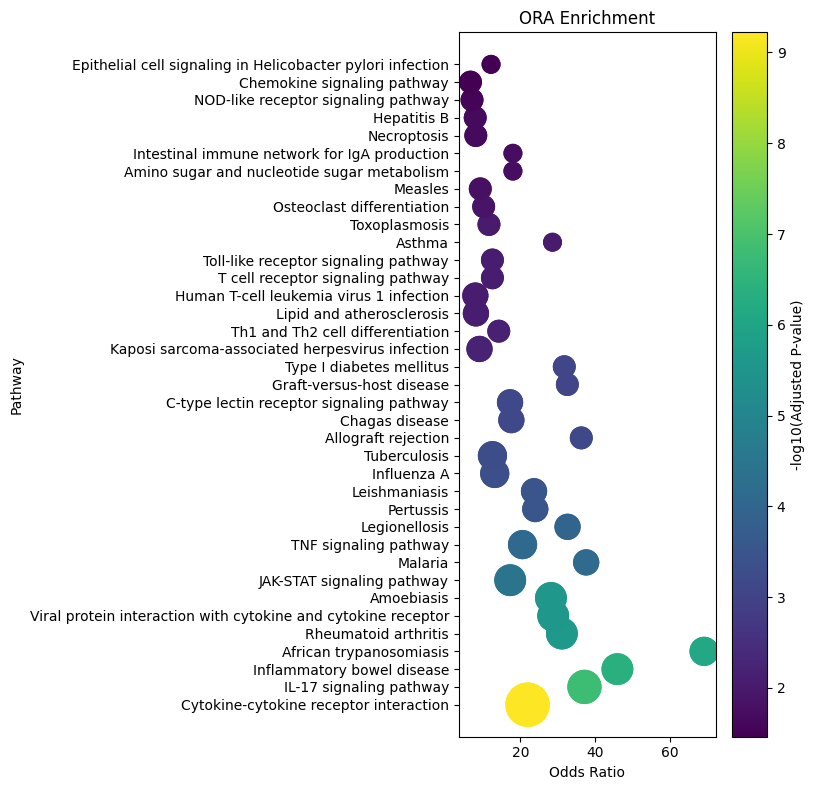

In [17]:
import numpy as np
import matplotlib.pyplot as plt


plot_df = sig_df.copy()


# overlap gene數量
plot_df["Gene_count"] = (
    plot_df["Overlap"]
    .str.split("/")
    .str[0]
    .astype(int)
)


# -log10 FDR
plot_df["-log10(FDR)"] = (
    -np.log10(plot_df["Adjusted P-value"])
)


plt.figure(figsize=(8,8))


plt.scatter(
    plot_df["Odds Ratio"],
    plot_df["Term"],
    s=plot_df["Gene_count"]*80,
    c=plot_df["-log10(FDR)"],
)

scatter = plt.scatter(
    plot_df["Odds Ratio"],
    plot_df["Term"],
    s=plot_df["Gene_count"]*80,
    c=plot_df["-log10(FDR)"],
    cmap="viridis"
)

# 加入colorbar
cbar = plt.colorbar(scatter)

cbar.set_label(
    "-log10(Adjusted P-value)"
)

plt.xlabel(
    "Odds Ratio"
)

plt.ylabel(
    "Pathway"
)

plt.title(
    "ORA Enrichment"
)


plt.tight_layout()

plt.show()

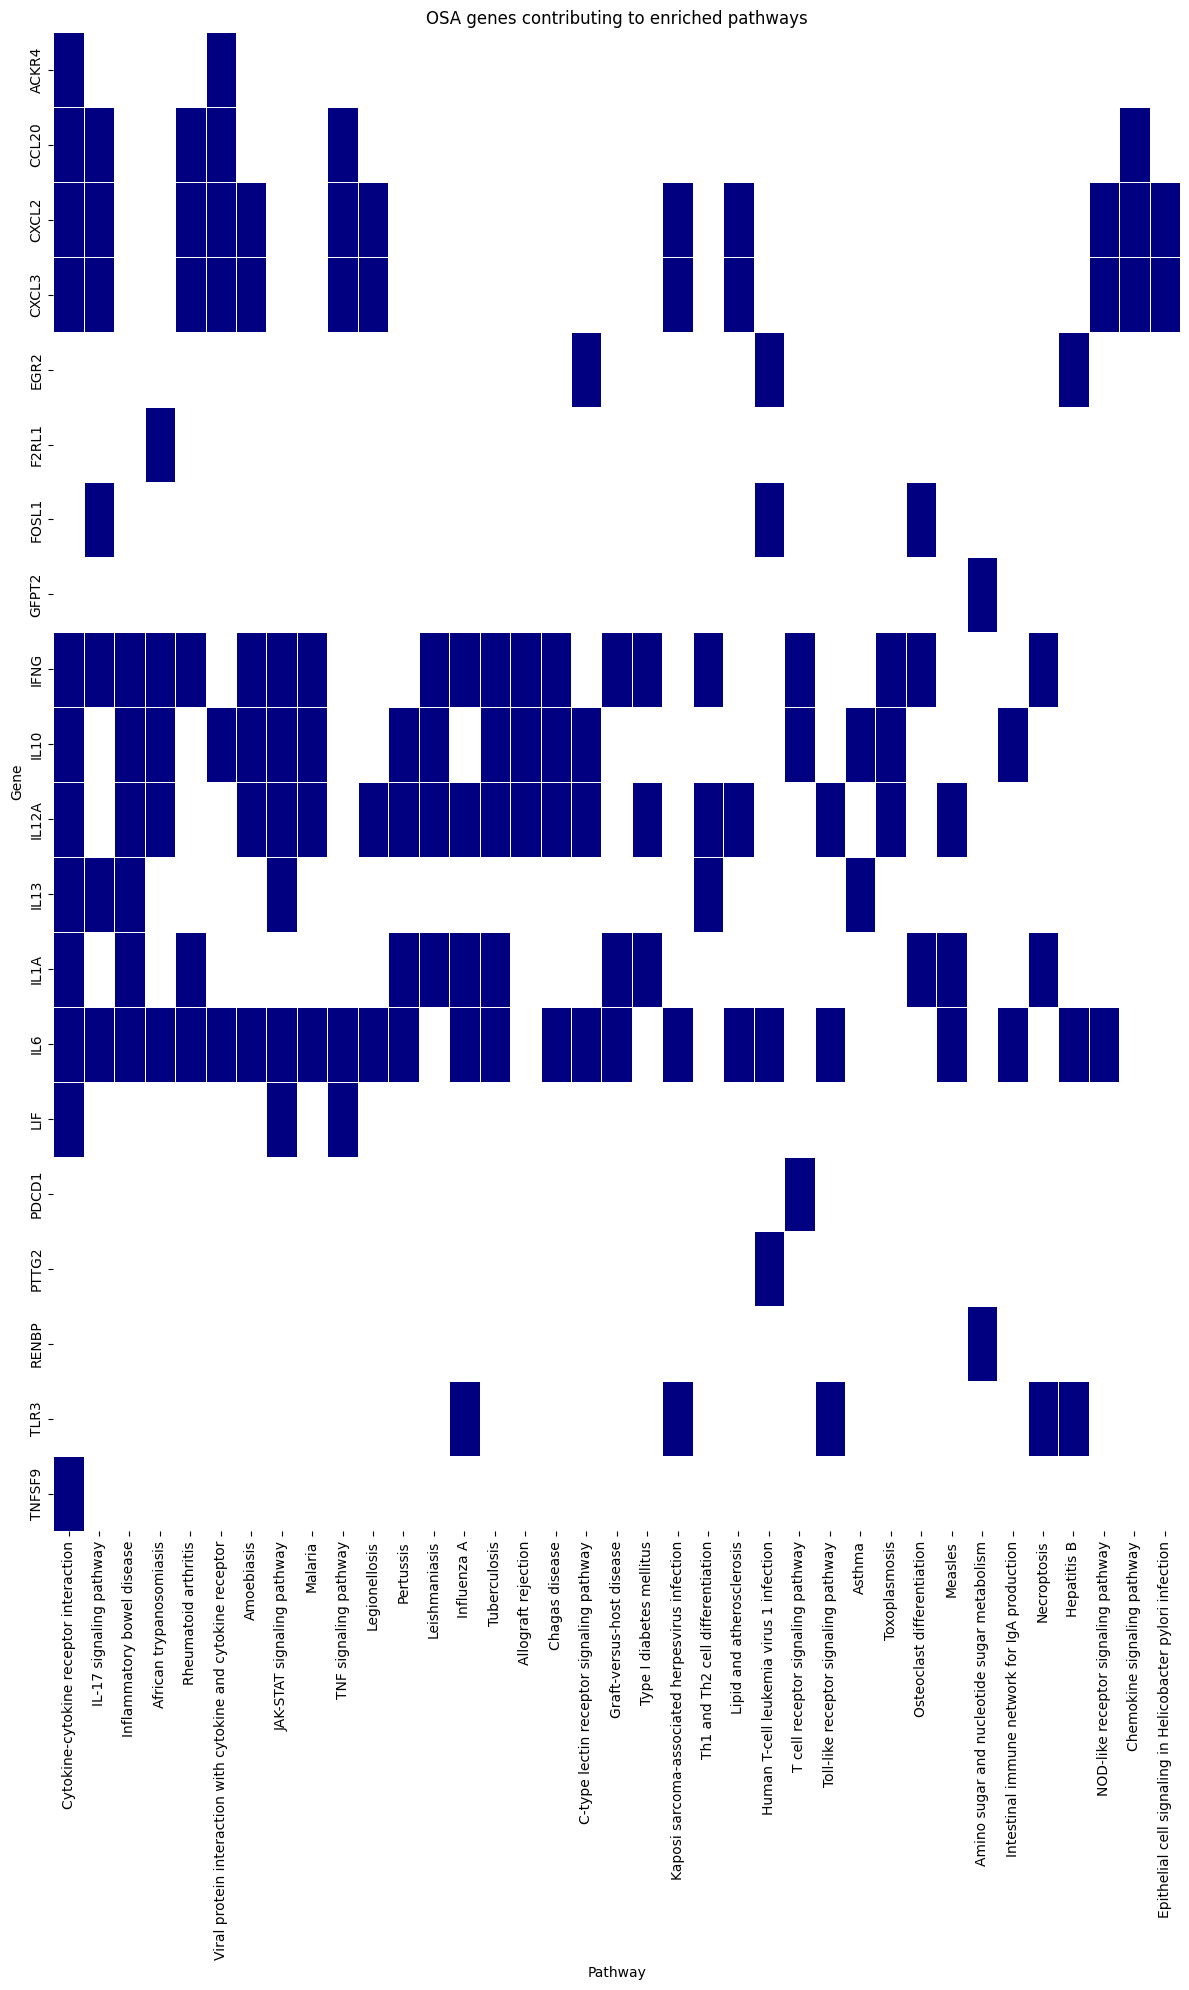

In [18]:
import seaborn as sns


top_pathway = sig_df


# 收集gene

all_genes = set()

for genes in top_pathway["Genes"]:

    all_genes.update(
        genes.split(";")
    )


all_genes = sorted(all_genes)



matrix = pd.DataFrame(
    0,
    index=all_genes,
    columns=top_pathway["Term"]
)



for _, row in top_pathway.iterrows():

    pathway = row["Term"]

    genes = row["Genes"].split(";")

    for gene in genes:

        matrix.loc[
            gene,
            pathway
        ] = 1


plt.figure(
    figsize=(12,20)
)


from matplotlib.colors import ListedColormap

cmap = ListedColormap(["white", "navy"])

sns.heatmap(
    matrix,
    cmap=cmap,
    vmin=0,
    vmax=1,
    linewidths=0.5,
    cbar=False
)

plt.xlabel(
    "Pathway"
)

plt.ylabel(
    "Gene"
)


plt.title(
    "OSA genes contributing to enriched pathways"
)


plt.tight_layout()

plt.show()

In [157]:
print(res_2.res2d.sort_values(
    by="FDR q-val",
    ascending=True
).head())

       Name                                               Term        ES  \
0   prerank                Post COVID Neuroinflammation WP5485  0.963206   
1   prerank          Cytokines And Inflammatory Response WP530  0.956417   
2   prerank  Development And Heterogeneity Of The ILC Famil...  0.925122   
11  prerank     Resistin As A Regulator Of Inflammation WP4481  0.882284   
5   prerank           Aryl Hydrocarbon Receptor Pathway WP2873  0.913082   

         NES  NOM p-val  FDR q-val  FWER p-val Tag % Gene %  \
0   1.676884   0.000000   0.005982       0.006  7/16  1.95%   
1   1.646518   0.001015   0.033399       0.050  6/17  1.37%   
2   1.601414   0.003015   0.190755       0.305  4/23  1.37%   
11  1.537218   0.021234   0.234871       0.766  2/18  0.55%   
5   1.569159   0.007092   0.240604       0.557  2/17  0.58%   

                            Lead_genes  
0   IL12A;IL10;IL6;IFNG;TLR3;IL1A;ACE2  
1        CXCL2;IL10;IL6;IFNG;IL1A;IL13  
2                  IL12A;IL6;IFNG;IL13  


In [158]:
sig_gsea = res_2.res2d[
    res_2.res2d["FDR q-val"] < 0.25
]

sig_gsea = sig_gsea.sort_values(
    by="FDR q-val",
    ascending=True
)

print(sig_gsea)
len(sig_gsea)

       Name                                               Term        ES  \
0   prerank                Post COVID Neuroinflammation WP5485  0.963206   
1   prerank          Cytokines And Inflammatory Response WP530  0.956417   
2   prerank  Development And Heterogeneity Of The ILC Famil...  0.925122   
11  prerank     Resistin As A Regulator Of Inflammation WP4481  0.882284   
5   prerank           Aryl Hydrocarbon Receptor Pathway WP2873  0.913082   
7   prerank        Inflammatory Bowel Disease Signaling WP5198  0.901752   
4   prerank  Extrafollicular And Follicular B Cell Activati...  0.922555   

         NES  NOM p-val  FDR q-val  FWER p-val Tag % Gene %  \
0   1.676884   0.000000   0.005982       0.006  7/16  1.95%   
1   1.646518   0.001015   0.033399       0.050  6/17  1.37%   
2   1.601414   0.003015   0.190755       0.305  4/23  1.37%   
11  1.537218   0.021234   0.234871       0.766  2/18  0.55%   
5   1.569159   0.007092   0.240604       0.557  2/17  0.58%   
7   1.554304 

7

In [159]:
Lead_genes = sig_gsea["Lead_genes"].to_list()

Lead_genes

['IL12A;IL10;IL6;IFNG;TLR3;IL1A;ACE2',
 'CXCL2;IL10;IL6;IFNG;IL1A;IL13',
 'IL12A;IL6;IFNG;IL13',
 'IL12A;IL6',
 'IL12A;IFNG',
 'IL12A;IL10;IL6;IFNG;IL1A;IL13',
 'IL12A;IL10;IL6;IFNG;PDCD1']

In [160]:
term = sig_gsea["Term"].to_list()

term

['Post COVID Neuroinflammation WP5485',
 'Cytokines And Inflammatory Response WP530',
 'Development And Heterogeneity Of The ILC Family WP3893',
 'Resistin As A Regulator Of Inflammation WP4481',
 'Aryl Hydrocarbon Receptor Pathway WP2873',
 'Inflammatory Bowel Disease Signaling WP5198',
 'Extrafollicular And Follicular B Cell Activation By SARS CoV 2 WP5218']

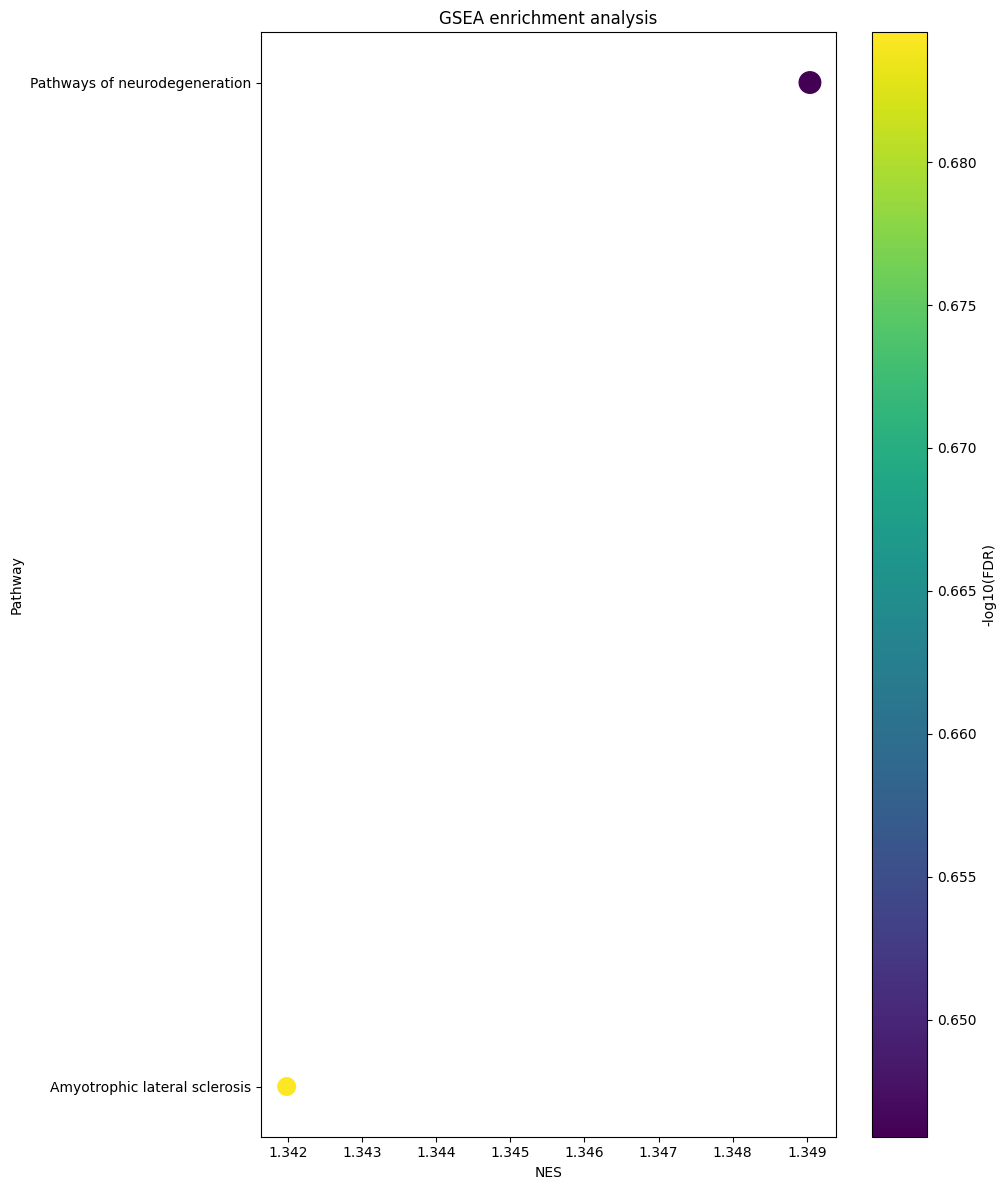

In [212]:
import matplotlib.pyplot as plt
import numpy as np


plot_df = sig_gsea.copy()


plot_df["Tag_count"] = (
    plot_df["Tag %"]
    .str.split("/")
    .str[0]
    .astype(int)
)


plt.figure(figsize=(10,12))


scatter = plt.scatter(
    plot_df["NES"],
    plot_df["Term"],
    s=plot_df["Tag_count"]*80,
    c=-np.log10(plot_df["FDR q-val"])
)


plt.colorbar(
    scatter,
    label="-log10(FDR)"
)


plt.xlabel(
    "NES"
)

plt.ylabel(
    "Pathway"
)


plt.title(
    "GSEA enrichment analysis"
)


plt.tight_layout()

plt.show()

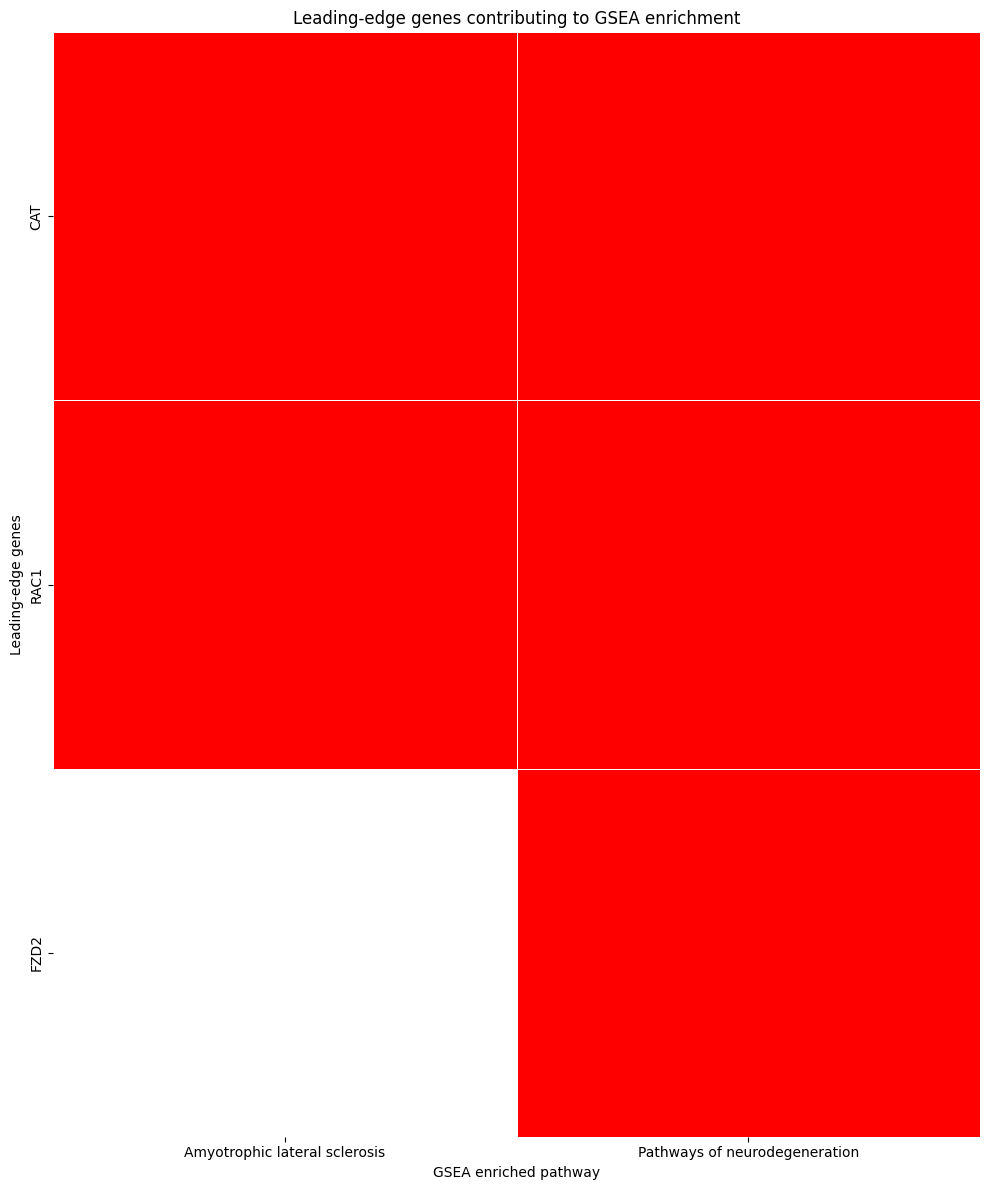

In [213]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap


top_pathway = sig_gsea.copy()


# =========================
# 收集 leading-edge genes
# =========================

all_genes = set()


for genes in top_pathway["Lead_genes"]:

    all_genes.update(
        genes.split(";")
    )


all_genes = sorted(all_genes)



# =========================
# 建立 0/1 matrix
# =========================

matrix = pd.DataFrame(
    0,
    index=all_genes,
    columns=top_pathway["Term"]
)



for _, row in top_pathway.iterrows():

    pathway = row["Term"]

    genes = row["Lead_genes"].split(";")


    for gene in genes:

        matrix.loc[
            gene,
            pathway
        ] = 1



# =========================
# gene排序
# 出現越多pathway越上面
# =========================

matrix = matrix.loc[
    matrix.sum(axis=1)
    .sort_values(ascending=False)
    .index
]



# =========================
# 畫binary heatmap
# =========================

plt.figure(
    figsize=(
        max(10, len(matrix.columns)*0.6),
        max(12, len(matrix.index)*0.25)
    )
)


cmap = ListedColormap(
    ["white", "red"]
)


sns.heatmap(
    matrix,
    cmap=cmap,
    linewidths=0.5,
    cbar=False
)


plt.xlabel(
    "GSEA enriched pathway"
)


plt.ylabel(
    "Leading-edge genes"
)


plt.title(
    "Leading-edge genes contributing to GSEA enrichment"
)


plt.tight_layout()

plt.show()